## Datenintegration BTC + XAU

In [9]:
import pandas as pd

# Pfade zu den bereinigten CSV-Dateien
df_btc = pd.read_csv('../dataset/output/BTCUSD_1d_analysis_clean.csv', parse_dates=['date_btc'])
df_xau = pd.read_csv('../dataset/output/XAUUSD_1d_analysis_clean.csv', parse_dates=['date_xau'])

# Spalten für Join vereinheitlichen
df_btc = df_btc.rename(columns={'date_btc': 'date'})
df_xau = df_xau.rename(columns={'date_xau': 'date'})

# Mergen der Datensätze anhand des Datums
merged_df = pd.merge(df_btc, df_xau, on='date', how='inner')

# Sortieren und Speichern
merged_df = merged_df.sort_values('date').reset_index(drop=True)
merged_df.to_csv('../dataset/output/final_merged_dataset.csv', index=False)
print(merged_df.head())

                       date  open_btc  high_btc  low_btc  close_btc  \
0 2014-11-28 00:00:00+00:00    363.59    381.34   360.57     376.28   
1 2014-12-01 00:00:00+00:00    376.40    382.31   373.03     378.39   
2 2014-12-02 00:00:00+00:00    378.39    382.86   375.23     379.25   
3 2014-12-03 00:00:00+00:00    379.25    383.00   374.23     376.67   
4 2014-12-04 00:00:00+00:00    376.67    378.99   360.01     365.20   

   volume_usd_btc open_xau high_xau  low_xau close_xau  volume_xau  
0         8617.15  1188.92  1190.64  1165.06   1165.88       68176  
1         6660.56  1158.49   1220.8  1141.74    1210.8      138509  
2         6832.53  1211.04  1212.51  1191.85    1198.5      104108  
3         7908.29  1197.07  1214.96  1194.22   1209.47       66218  
4         8865.09  1208.55  1213.28  1201.17   1205.45       64221  


## Berechnungen

In [23]:
import pandas as pd
import numpy as np
from scipy import stats

# Datensatz laden
df = pd.read_csv('../dataset/output/final_merged_dataset.csv', parse_dates=['date'])

# Bootstrap-Funktion
def bootstrap_ci(data, func, n=1000, ci=0.95):
    boot_samples = [func(np.random.choice(data, size=len(data), replace=True)) for _ in range(n)]
    lower = np.percentile(boot_samples, (1 - ci) / 2 * 100)
    upper = np.percentile(boot_samples, (1 + ci) / 2 * 100)
    return (lower, upper)

# Statistiken mit Konfidenzintervallen berechnen
def beschreibung(name, daten):
    daten = daten.dropna().values
    print(f"\n{name}")

    mean = np.mean(daten)
    median = np.median(daten)
    std = np.std(daten, ddof=1)
    iqr = np.percentile(daten, 75) - np.percentile(daten, 25)

    print(f"Mittelwert: {mean:.2f}")
    print(f"Median: {median:.2f}")
    print(f"Standardabweichung: {std:.2f}")
    print(f"IQR: {iqr:.2f}")

    # Konfidenzintervalle
    ci_mean = stats.t.interval(0.95, len(daten)-1, loc=mean, scale=stats.sem(daten))
    ci_median = bootstrap_ci(daten, np.median)
    ci_std = bootstrap_ci(daten, lambda x: np.std(x, ddof=1))
    ci_iqr = bootstrap_ci(daten, lambda x: np.percentile(x, 75) - np.percentile(x, 25))

    print(f"95% CI Mittelwert: ({ci_mean[0]:.2f}, {ci_mean[1]:.2f})")
    print(f"95% CI Median: ({ci_median[0]:.2f}, {ci_median[1]:.2f})")
    print(f"95% CI Standardabw.: ({ci_std[0]:.2f}, {ci_std[1]:.2f})")
    print(f"95% CI IQR: ({ci_iqr[0]:.2f}, {ci_iqr[1]:.2f})")

# Aufruf für BTC und XAU
beschreibung("BTC Schlusskurs (close_btc)", df['close_btc'])
beschreibung("XAU Schlusskurs (close_xau)", df['close_xau'])




BTC Schlusskurs (close_btc)
Mittelwert: 20518.35
Median: 9635.40
Standardabweichung: 23199.40
IQR: 30377.52
95% CI Mittelwert: (19629.27, 21407.43)
95% CI Median: (9280.85, 10203.65)
95% CI Standardabw.: (22400.26, 23972.62)
95% CI IQR: (27731.06, 33647.98)

XAU Schlusskurs (close_xau)
Mittelwert: 1607.55
Median: 1527.12
Standardabweichung: 403.14
IQR: 612.96
95% CI Mittelwert: (1592.11, 1623.00)
95% CI Median: (1492.78, 1595.57)
95% CI Standardabw.: (391.90, 413.98)
95% CI IQR: (598.71, 631.68)


## Preisentwicklung von BTC und XAU

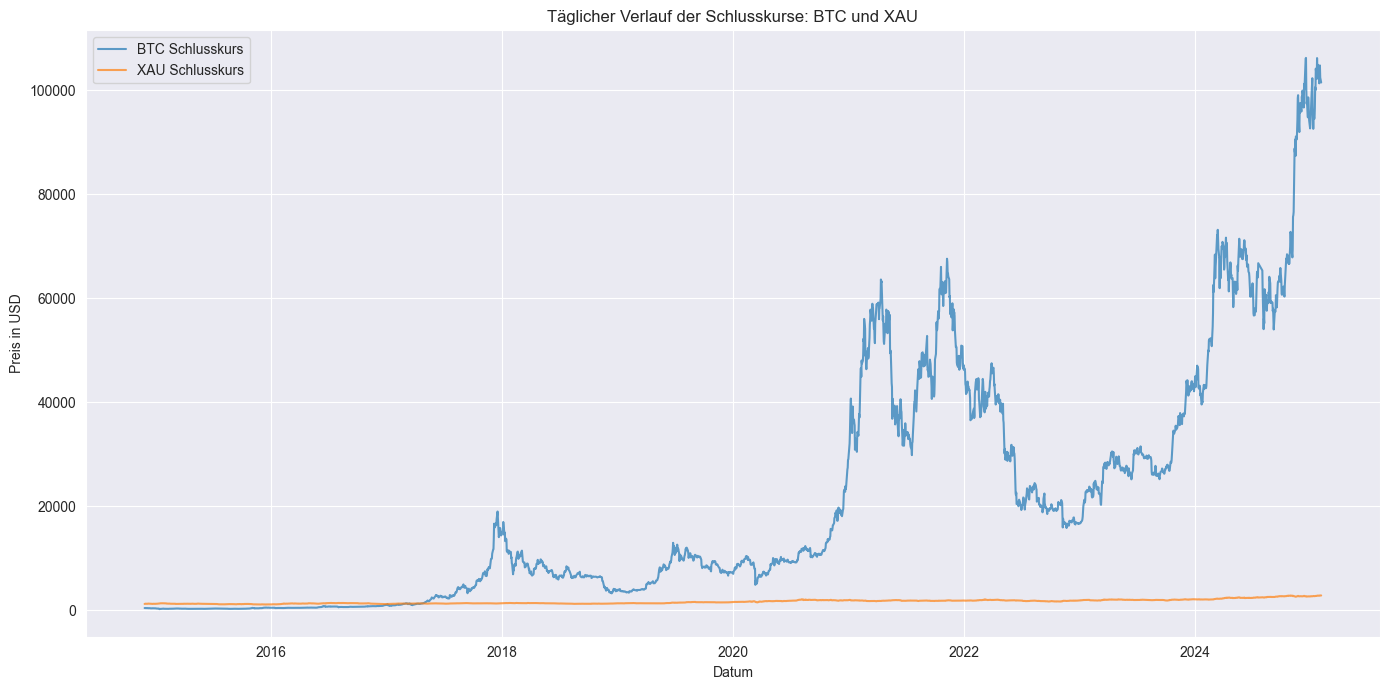

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Datensatz laden (aus final_merged_dataset.csv)
df = pd.read_csv('../dataset/output/final_merged_dataset.csv', parse_dates=['date'])

# Tagesdiagramm BTC und XAU Schlusskurse
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['close_btc'], label='BTC Schlusskurs', alpha=0.7)
plt.plot(df['date'], df['close_xau'], label='XAU Schlusskurs', alpha=0.7)
plt.title('Täglicher Verlauf der Schlusskurse: BTC und XAU')
plt.xlabel('Datum')
plt.ylabel('Preis in USD')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Preisentwicklung von BTC und XAU mit logarithmischer Skala

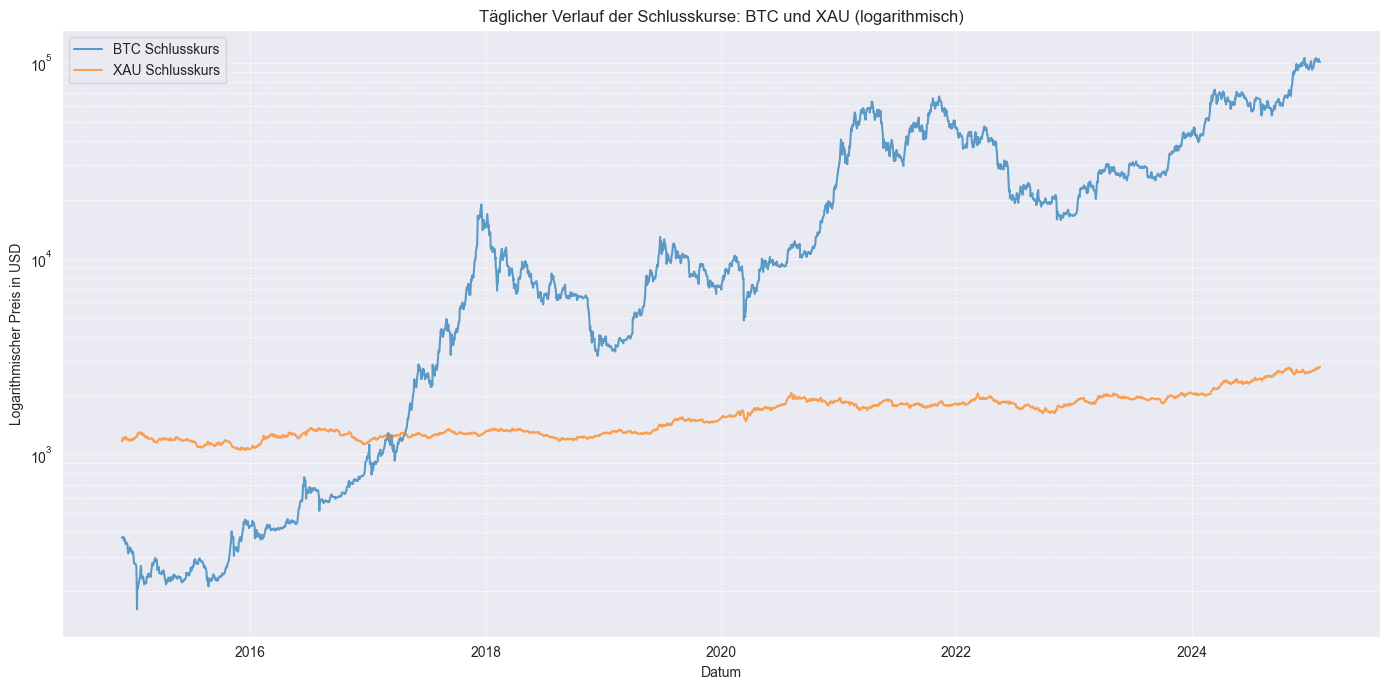

In [10]:
# Plot
plt.figure(figsize=(14, 7))
plt.plot(df['date'], df['close_btc'], label='BTC Schlusskurs', alpha=0.7)
plt.plot(df['date'], df['close_xau'], label='XAU Schlusskurs', alpha=0.7)

# Logarithmische Y-Achse
plt.yscale('log')

# Diagrammgestaltung
plt.title('Täglicher Verlauf der Schlusskurse: BTC und XAU (logarithmisch)')
plt.xlabel('Datum')
plt.ylabel('Logarithmischer Preis in USD')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


## Korrelation der Schlusskurse

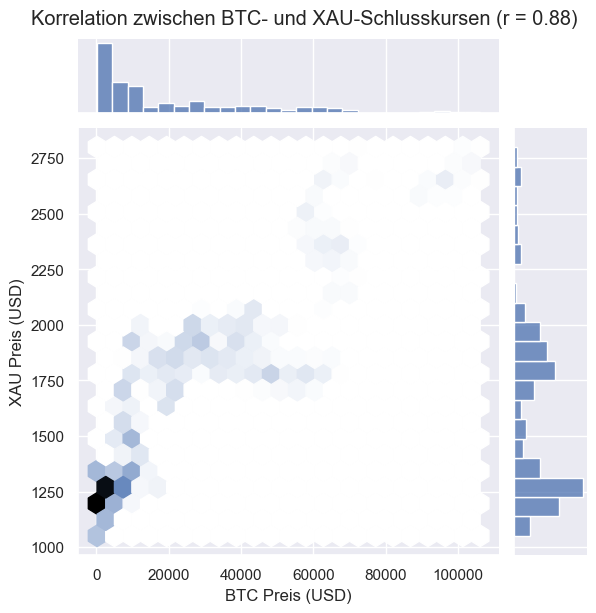

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df['close_btc'].corr(df['close_xau'])

sns.jointplot(x='close_btc', y='close_xau', data=df, kind='hex')
plt.suptitle(f"Korrelation zwischen BTC- und XAU-Schlusskursen (r = {corr:.2f})", y=1.02)
plt.xlabel("BTC Preis (USD)")
plt.ylabel("XAU Preis (USD)")
plt.show()


## Scatterplot

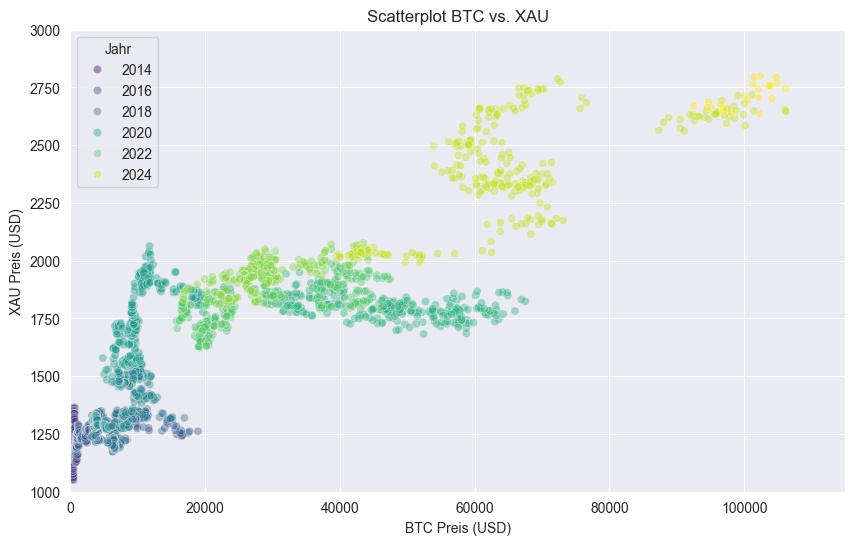

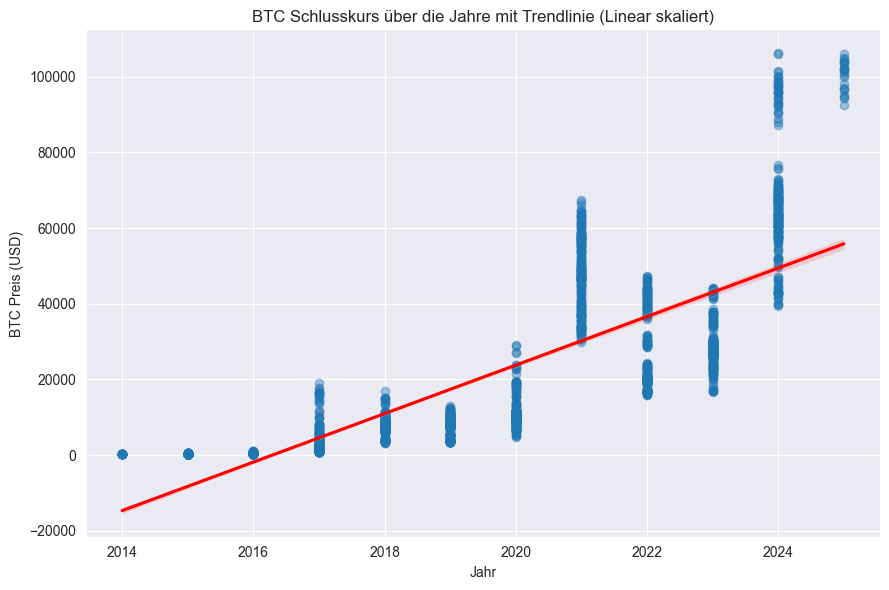

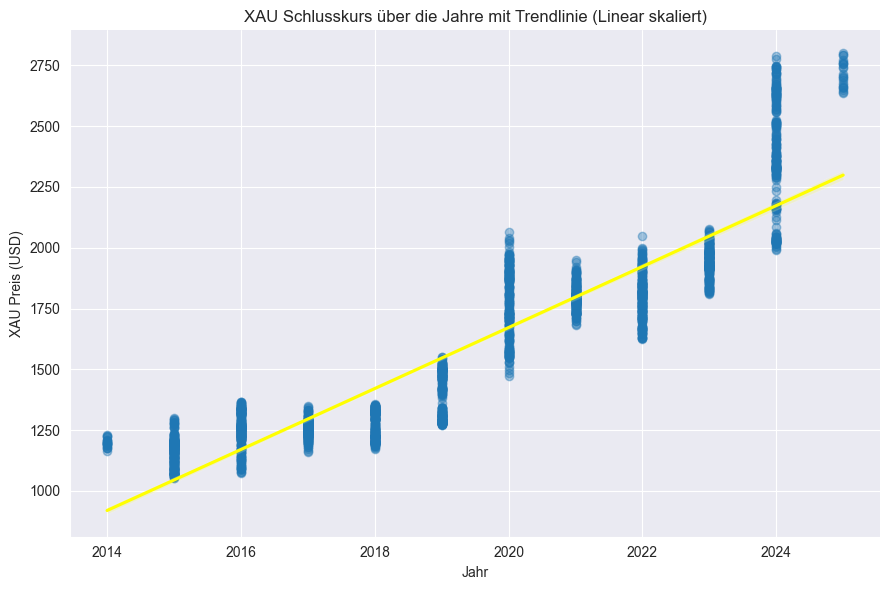

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------------------------
# Scatterplot für BTC & XAU ohne Trendlinie
# --------------------------------------------------------------------

# Jahr extrahieren
df['year'] = df['date'].dt.year

plt.figure(figsize=(10, 6))
sns.scatterplot(x='close_btc', y='close_xau', hue='year', data=df, palette='viridis', alpha=0.4, legend='brief')
plt.title("Scatterplot BTC vs. XAU")
plt.xlabel("BTC Preis (USD)")
plt.ylabel("XAU Preis (USD)")
plt.xlim(0, 115000)
plt.ylim(1000, 3000)
plt.grid(True)
plt.legend(title='Jahr')
plt.show()


# --------------------------------------------------------------------
# Scatterplot für BTC & XAU mit Trendlinie
# --------------------------------------------------------------------

sns.lmplot(
    x='year', y='close_btc', data=df,
    scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'},
    height=6, aspect=1.5
)
plt.title("BTC Schlusskurs über die Jahre mit Trendlinie (Linear skaliert)")
plt.xlabel("Jahr")
plt.ylabel("BTC Preis (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Scatterplot für XAU mit Trendlinie
sns.lmplot(
    x='year', y='close_xau', data=df,
    scatter_kws={'alpha': 0.4}, line_kws={'color': 'yellow'},
    height=6, aspect=1.5
)
plt.title("XAU Schlusskurs über die Jahre mit Trendlinie (Linear skaliert)")
plt.xlabel("Jahr")
plt.ylabel("XAU Preis (USD)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Boxplot der täglichen Renditen von Bitcoin (BTC) und Gold (XAU)

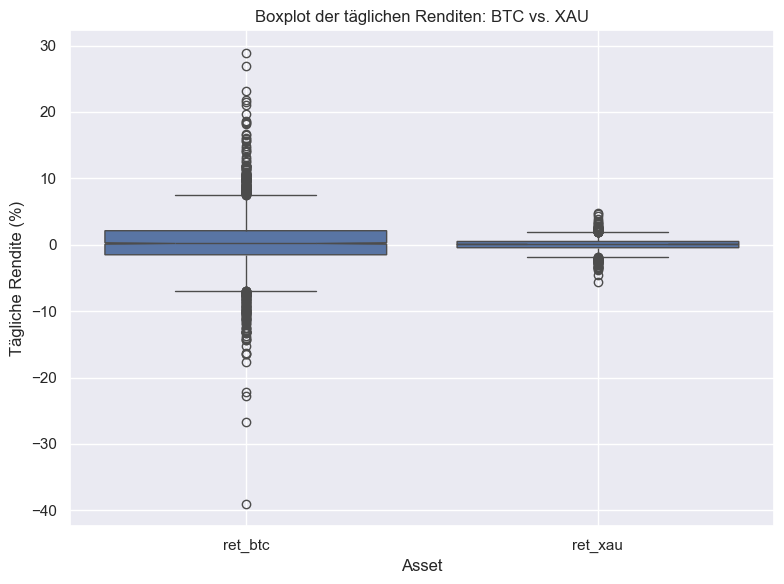

In [19]:
# Tägliche Renditen berechnen (in %)
df['ret_btc'] = df['close_btc'].pct_change() * 100
df['ret_xau'] = df['close_xau'].pct_change() * 100

# Daten vorbereiten (für Seaborn)
returns_df = df[['ret_btc', 'ret_xau']].dropna()
returns_df = returns_df.melt(var_name='Asset', value_name='Tägliche Rendite (%)')

# Boxplot erstellen
plt.figure(figsize=(8, 6))
sns.boxplot(x='Asset', y='Tägliche Rendite (%)', data=returns_df, notch=True)
plt.title("Boxplot der täglichen Renditen: BTC vs. XAU")
plt.grid(True)
plt.tight_layout()
plt.show()


## Hexagonales Binning für Tägliche Rendite BTC vs. XAU

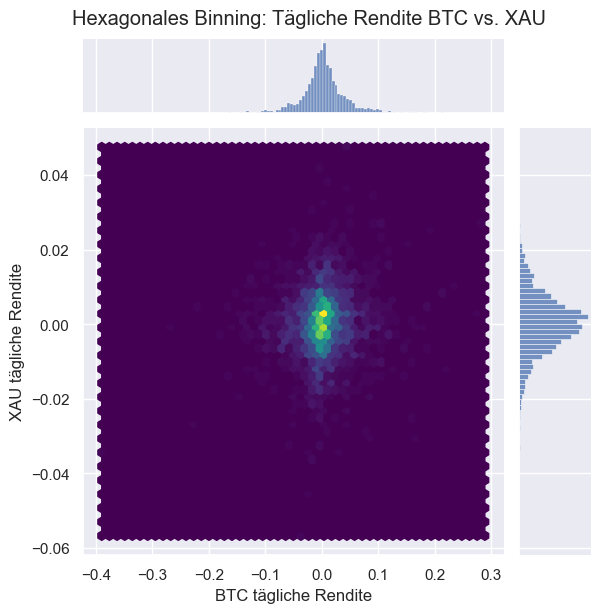

In [23]:
# Entferne NaN-Werte, die durch die Verschiebung entstehen
df_returns = df.dropna(subset=['return_btc', 'return_xau'])

# Hexagonales Binning
sns.jointplot(
    x='return_btc',
    y='return_xau',
    data=df_returns,
    kind='hex',
    gridsize=50,
    cmap='viridis'
)

plt.suptitle("Hexagonales Binning: Tägliche Rendite BTC vs. XAU", y=1.02)
plt.xlabel("BTC tägliche Rendite")
plt.ylabel("XAU tägliche Rendite")
plt.show()


## Kontingenztabelle: Die tägliche Rendite für BTC & XAU

In [25]:
# Tägliche Renditen berechnen
df['ret_btc'] = df['close_btc'].pct_change() * 100
df['ret_xau'] = df['close_xau'].pct_change() * 100

# Kategorisierung: Steigend / Neutral / Fallend
def categorize_return(x):
    if x > 0.5:
        return 'Steigend'
    elif x < -0.5:
        return 'Fallend'
    else:
        return 'Neutral'

df['btc_cat'] = df['ret_btc'].apply(categorize_return)
df['xau_cat'] = df['ret_xau'].apply(categorize_return)

# ✅ Kontingenztabelle erzeugen
ct1 = pd.crosstab(df['btc_cat'], df['xau_cat'])
print("Kontingenztabelle - BTC-Renditekategorie vs. XAU-Renditekategorie:\n")
print(ct1)


Kontingenztabelle - BTC-Renditekategorie vs. XAU-Renditekategorie:

xau_cat   Fallend  Neutral  Steigend
btc_cat                             
Fallend       248      533       225
Neutral       111      238       100
Steigend      238      594       331


## Kontingenztabelle: Analyse der Preisbereiche von Bitcoin und Gold

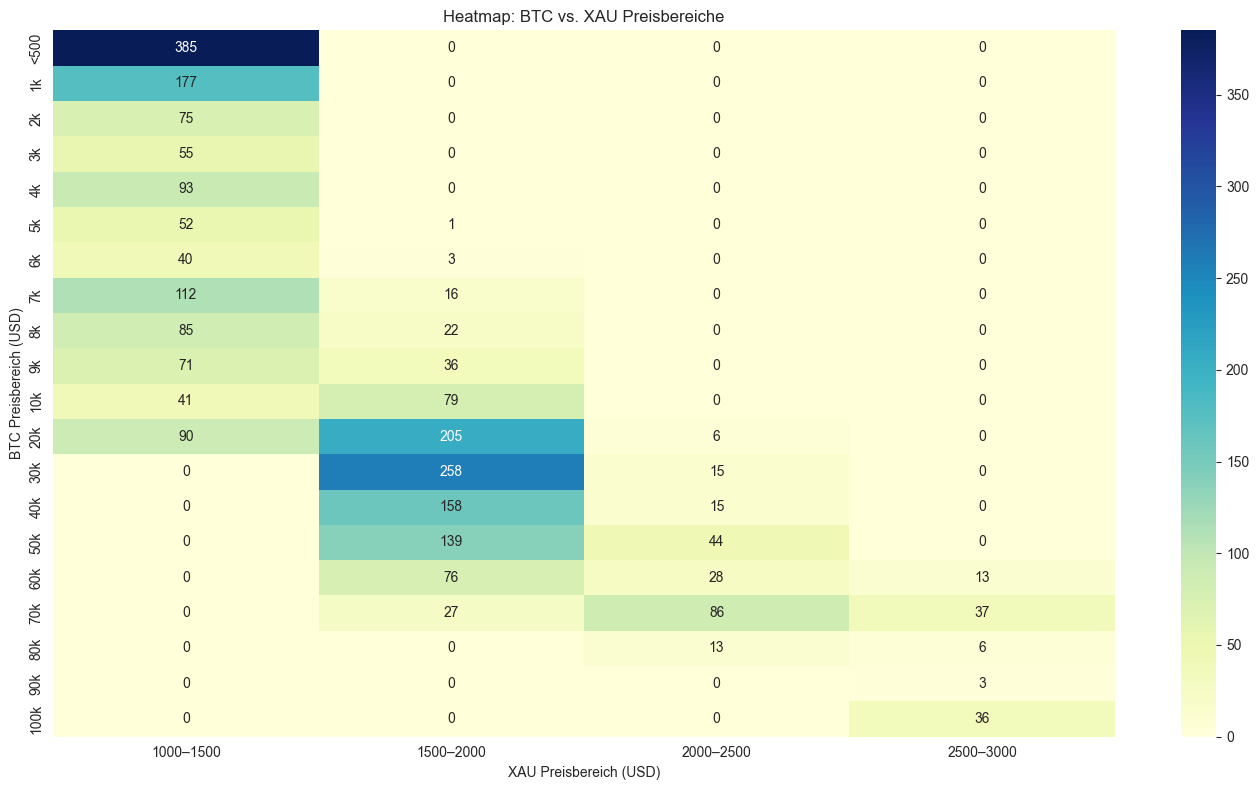

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Finalen Datensatz laden
merged_df = pd.read_csv('../dataset/output/final_merged_dataset.csv', parse_dates=['date'])

# Preisgrenzen definieren
btc_bins = [0, 500] + list(range(1000, 11000, 1000)) + list(range(20000, 110000, 10000))
xau_bins = [0, 500, 1000, 1500, 2000, 2500, 3000]

# Labels erstellen
btc_labels = ['<500'] + [f'{i//1000}k' for i in btc_bins[2:]]
xau_labels = [f'{xau_bins[i]}–{xau_bins[i+1]}' for i in range(len(xau_bins)-1)]

# Preisbereiche zuordnen
merged_df['btc_range'] = pd.cut(merged_df['close_btc'], bins=btc_bins, labels=btc_labels)
merged_df['xau_range'] = pd.cut(merged_df['close_xau'], bins=xau_bins, labels=xau_labels)

# Visualisierung mit Heatmap anzeigen
plt.figure(figsize=(14, 8))
sns.heatmap(range_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Heatmap: BTC vs. XAU Preisbereiche")
plt.xlabel("XAU Preisbereich (USD)")
plt.ylabel("BTC Preisbereich (USD)")
plt.tight_layout()
plt.show()

## Kontingenztabelle

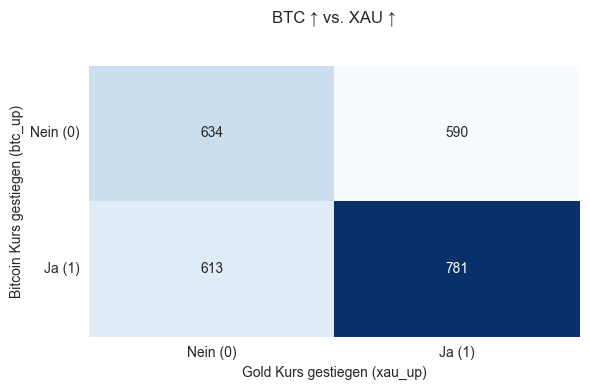

In [100]:
# Kursveränderungen berechnen
df['btc_up'] = (df['close_btc'].pct_change() > 0).astype(int)
df['xau_up'] = (df['close_xau'].pct_change() > 0).astype(int)

# Kontingenztabelle erstellen
df_clean = df[['btc_up', 'xau_up']].dropna()
contingency_table = pd.crosstab(df_clean['btc_up'], df_clean['xau_up'])

# Anzeige der Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("BTC ↑ vs. XAU ↑\n\n")
plt.xlabel("Gold Kurs gestiegen (xau_up)")
plt.ylabel("Bitcoin Kurs gestiegen (btc_up)")
plt.xticks([0.5, 1.5], ["Nein (0)", "Ja (1)"])
plt.yticks([0.5, 1.5], ["Nein (0)", "Ja (1)"], rotation=0)
plt.tight_layout()
plt.show()


## Chi²-Test
* Gibt es signifikanter Zusammenhang zwischen Kursveränderungen von Bitcoin und Gold?

Bootstrapping Chi²: 100%|██████████| 1000/1000 [00:00<00:00, 5614.45it/s]



📊 Bootstrap-Chi²-Test Ergebnisse:
Beobachtete Chi²-Statistik: 15.6791
Empirischer p-Wert: 0.0000
Freiheitsgrade: 1

✅ Ergebnis: Signifikanter Zusammenhang zwischen Kursveränderungen von Bitcoin und Gold.


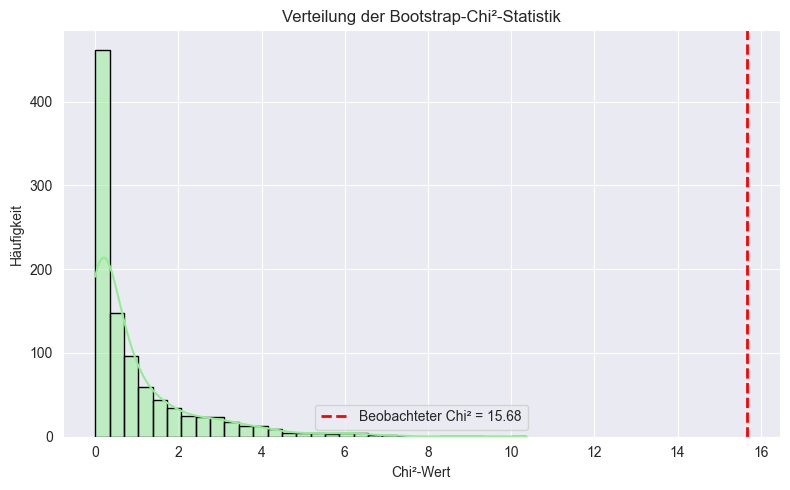

In [96]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from tqdm import tqdm

# Klassischer Chi²-Test zur Referenz
chi2_obs, p, dof, expected = chi2_contingency(contingency_table)

# Bootstrap-Simulation
n_iter = 1000
chi2_boot = []

np.random.seed(42)
observed = contingency_table.values
total = observed.sum()
row_totals = observed.sum(axis=1)
col_totals = observed.sum(axis=0)

for _ in tqdm(range(n_iter), desc="Bootstrapping Chi²"):
    expected_flat = (np.outer(row_totals, col_totals) / total).flatten()
    simulated = np.random.multinomial(total, expected_flat / total)
    simulated_table = simulated.reshape(observed.shape)
    chi2_sim, _, _, _ = chi2_contingency(simulated_table)
    chi2_boot.append(chi2_sim)

# Empirischer p-Wert
p_emp = np.mean(np.array(chi2_boot) >= chi2_obs)

# Ergebnis
print("\n📊 Bootstrap-Chi²-Test Ergebnisse:")
print(f"Beobachtete Chi²-Statistik: {chi2_obs:.4f}")
print(f"Empirischer p-Wert: {p_emp:.4f}")
print(f"Freiheitsgrade: {dof}")

if p_emp < 0.05:
    print("\n✅ Ergebnis: Signifikanter Zusammenhang zwischen Kursveränderungen von Bitcoin und Gold.")
else:
    print("\n❌ Ergebnis: Kein signifikanter Zusammenhang zwischen Kursveränderungen von Bitcoin und Gold.")

# Visualisierung der Bootstrap-Chi²-Verteilung
plt.figure(figsize=(8, 5))
sns.histplot(chi2_boot, bins=30, kde=True, color="lightgreen", edgecolor="black")
plt.axvline(chi2_obs, color='red', linestyle='--', linewidth=2, label=f"Beobachteter Chi² = {chi2_obs:.2f}")
plt.title("Verteilung der Bootstrap-Chi²-Statistik")
plt.xlabel("Chi²-Wert")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 1. ANOVA
* Testet, ob Asset (BTC vs. XAU), Jahr, oder ihre Interaktion signifikant den Mittelwert der Rendite beeinflussen.
* Wenn C(asset):C(year) signifikant → die Renditeunterschiede zwischen BTC und XAU hängen vom Jahr ab.

In [81]:
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols
import statsmodels.api as sm
from tqdm import tqdm

# Long-Format vorbereiten
returns = pd.concat([
    df[['year', 'ret_btc']].rename(columns={'ret_btc': 'ret'}).assign(asset='BTC'),
    df[['year', 'ret_xau']].rename(columns={'ret_xau': 'ret'}).assign(asset='XAU')
]).dropna()

# Originalmodell und F-Werte
model_orig = ols('ret ~ C(asset) * C(year)', data=returns).fit()
anova_orig = sm.stats.anova_lm(model_orig, typ=2)
f_vals_orig = anova_orig['F'].dropna()

# Bootstrap-Sampling
n_iter = 1000
f_bootstrap = {effect: [] for effect in f_vals_orig.index}

np.random.seed(42)
for _ in tqdm(range(n_iter), desc="Bootstrapping ANOVA"):
    # Shuffle Residuen
    sampled = returns.copy()
    sampled['ret'] = np.random.choice(returns['ret'].values, size=len(returns), replace=True)

    # Modell neu schätzen
    model = ols('ret ~ C(asset) * C(year)', data=sampled).fit()
    anova = sm.stats.anova_lm(model, typ=2)

    for effect in f_bootstrap:
        f_bootstrap[effect].append(anova.loc[effect, 'F'])

# Empirische p-Werte berechnen
emp_p_vals = {
    effect: np.mean(np.array(f_bootstrap[effect]) >= f_vals_orig[effect])
    for effect in f_vals_orig.index
}

# Formatieren
results_df = pd.DataFrame({
    'F-Wert (orig)': f_vals_orig.round(4),
    'emp. p-Wert': pd.Series(emp_p_vals).round(4)
})

# Umbenennen für bessere Lesbarkeit
results_df.index = results_df.index.map({
    'C(asset)': 'Asset (BTC vs XAU)',
    'C(year)': 'Jahr',
    'C(asset):C(year)': 'Asset × Jahr'
})

print("\n📊 Bootstrap-ANOVA: Einfluss von Asset und Jahr auf Rendite")
print(results_df)

# Interpretation
print("\n📌 Interpretation der Bootstrap-ANOVA:")
for label, p_val in results_df['emp. p-Wert'].items():
    if p_val < 0.05:
        print(f"✅ {label}: Signifikanter Effekt (emp. p = {p_val:.4f})")
    else:
        print(f"❌ {label}: Kein signifikanter Effekt (emp. p = {p_val:.4f})")


Bootstrapping ANOVA: 100%|██████████| 1000/1000 [00:42<00:00, 23.26it/s]


📊 Bootstrap-ANOVA: Einfluss von Asset und Jahr auf Rendite
                    F-Wert (orig)  emp. p-Wert
Asset (BTC vs XAU)         9.9242        0.001
Jahr                       2.6123        0.003
Asset × Jahr               2.1557        0.020

📌 Interpretation der Bootstrap-ANOVA:
✅ Asset (BTC vs XAU): Signifikanter Effekt (emp. p = 0.0010)
✅ Jahr: Signifikanter Effekt (emp. p = 0.0030)
✅ Asset × Jahr: Signifikanter Effekt (emp. p = 0.0200)


##  2. ANOVA
* Unterscheiden sich die durchschnittlichen monatlichen Renditen von Bitcoin signifikant voneinander?

Bootstrapping Monats-ANOVA: 100%|██████████| 1000/1000 [00:15<00:00, 66.26it/s]



📊 Einfaktorielle Bootstrap-ANOVA: Unterschied der BTC-Monatsrenditen
F-Wert (original): 1.0769
Empirischer p-Wert: 0.3700

❌ Ergebnis: Kein signifikanter Unterschied zwischen den Monaten.


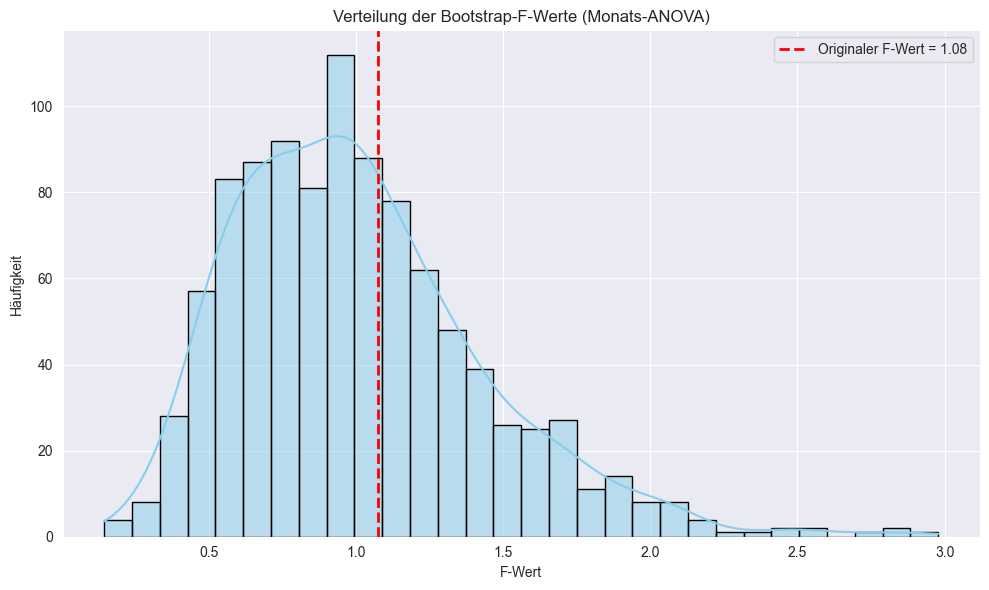

In [92]:
# Rendite berechnen
df['ret_btc'] = df['close_btc'].pct_change()

# Monat extrahieren und auf Monatsrenditen einschränken
df['month'] = df['date'].dt.month
monthly_returns = df[['month', 'ret_btc']].dropna()


# Originales ANOVA-Modell
model_orig = ols('ret_btc ~ C(month)', data=monthly_returns).fit()
anova_orig = sm.stats.anova_lm(model_orig, typ=2)
f_orig = anova_orig.loc['C(month)', 'F']

# Bootstrap: Verteilung der F-Werte
n_iter = 1000
f_boot = []

np.random.seed(42)
for _ in tqdm(range(n_iter), desc="Bootstrapping Monats-ANOVA"):
    sampled = monthly_returns.copy()
    sampled['ret_btc'] = np.random.choice(monthly_returns['ret_btc'], size=len(monthly_returns), replace=True)

    model = ols('ret_btc ~ C(month)', data=sampled).fit()
    anova = sm.stats.anova_lm(model, typ=2)
    f_boot.append(anova.loc['C(month)', 'F'])

# Empirischer p-Wert
p_emp = np.mean(np.array(f_boot) >= f_orig)

# Ergebnis
print("\n📊 Einfaktorielle Bootstrap-ANOVA: Unterschied der BTC-Monatsrenditen")
print(f"F-Wert (original): {f_orig:.4f}")
print(f"Empirischer p-Wert: {p_emp:.4f}")

if p_emp < 0.05:
    print("\n✅ Ergebnis: Die durchschnittlichen monatlichen Renditen unterscheiden sich signifikant.")
else:
    print("\n❌ Ergebnis: Kein signifikanter Unterschied zwischen den Monaten.")


plt.figure(figsize=(10, 6))
sns.histplot(f_boot, bins=30, kde=True, color='skyblue', edgecolor='black')
plt.axvline(f_orig, color='red', linestyle='--', linewidth=2, label=f'Originaler F-Wert = {f_orig:.2f}')
plt.title("Verteilung der Bootstrap-F-Werte (Monats-ANOVA)")
plt.xlabel("F-Wert")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## t-Test
* Volatilitätsanalyse (über absolute tägliche Renditen)

Bootstrap zur Volatilitätsanalyse (absolute tägliche Renditen)

Mittlere Differenz der Volatilitäten (BTC - XAU): 0.0222
95%-Konfidenzintervall: [0.0209, 0.0235]

✅ Ergebnis: Die Volatilität unterscheidet sich signifikant zwischen BTC und XAU.



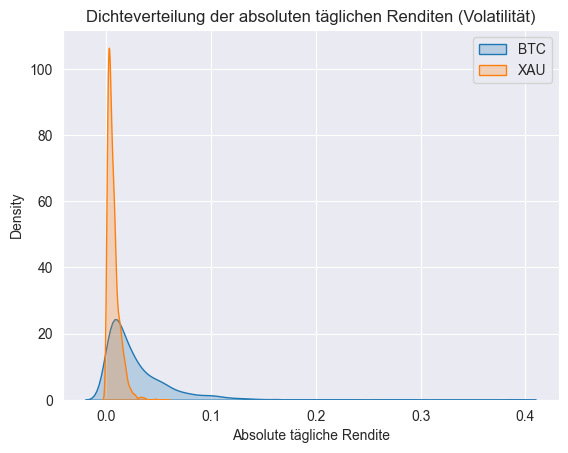

In [71]:
# Tägliche Renditen berechnen
df['ret_btc'] = df['close_btc'].pct_change()
df['ret_xau'] = df['close_xau'].pct_change()

# Volatilitäts-Proxy: absolute tägliche Renditen
vol_btc = np.abs(df['ret_btc'].dropna())
vol_xau = np.abs(df['ret_xau'].dropna())

# Kürzen auf gemeinsame Länge
min_len = min(len(vol_btc), len(vol_xau))
vol_btc = vol_btc[:min_len].values
vol_xau = vol_xau[:min_len].values

# Bootstrap-Sampling
n_iterations = 10000
np.random.seed(42)

boot_diffs = []
for _ in range(n_iterations):
    sample_btc = np.random.choice(vol_btc, size=min_len, replace=True)
    sample_xau = np.random.choice(vol_xau, size=min_len, replace=True)
    boot_diffs.append(np.mean(sample_btc) - np.mean(sample_xau))

boot_diffs = np.array(boot_diffs)

# Konfidenzintervall berechnen (z. B. 95 %)
ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

# Ergebnisinterpretation
print("Volatilitätsanalyse (absolute tägliche Renditen)\n")
print(f"Mittlere Differenz der Volatilitäten (BTC - XAU): {np.mean(boot_diffs):.4f}")
print(f"95%-Konfidenzintervall: [{ci_lower:.4f}, {ci_upper:.4f}]")

if ci_lower > 0 or ci_upper < 0:
    print("\n✅ Ergebnis: Die Volatilität unterscheidet sich signifikant zwischen BTC und XAU.\n")
else:
    print("\n❌ Ergebnis: Kein signifikanter Unterschied in der Volatilität.\n")

# Visualisierung
sns.kdeplot(vol_btc, label='BTC', fill=True)
sns.kdeplot(vol_xau, label='XAU', fill=True)
plt.title("Dichteverteilung der absoluten täglichen Renditen (Volatilität)")
plt.xlabel("Absolute tägliche Rendite")
plt.legend()
plt.grid(True)
plt.show()